In [1]:
!pip install gdown -q

In [2]:
!gdown 1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs -O trader_data.csv
!gdown 1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf -O fear_greed.csv

Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trader_data.csv
100% 47.5M/47.5M [00:01<00:00, 35.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed.csv
100% 90.8k/90.8k [00:00<00:00, 74.4MB/s]


In [3]:
import pandas as pd

trader_df = pd.read_csv('trader_data.csv')
fear_df = pd.read_csv('fear_greed.csv')

print(trader_df.shape)
print(trader_df.head())
print(fear_df.shape)
print(fear_df.head())

(211224, 16)
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         

In [4]:
# Check the range of the numeric 'Timestamp' column in trader data.
# We don't yet know if this is in seconds or milliseconds since epoch (1970-01-01),
# so we're just printing raw min/max first before converting anything.
print(trader_df['Timestamp'].min(), trader_df['Timestamp'].max())

# Check the range of the string 'Timestamp IST' column.
# This should be human-readable (DD-MM-YYYY HH:MM format based on the sample row),
# so min/max here is just a sanity check that dates look reasonable (not garbage).
print(trader_df['Timestamp IST'].min(), trader_df['Timestamp IST'].max())

# Check the date range of the Fear/Greed dataset.
# We already know it starts 2018-02-01 from the head() output — this gets the end date.
# This matters because if trader_df's dates fall outside this range,
# those rows won't find a match when we merge later (they'll become NaN).
print(fear_df['date'].min(), fear_df['date'].max())

1680000000000.0 1750000000000.0
01-01-2024 01:23 31-12-2024 23:33
2018-02-01 2025-05-02


In [5]:
# Convert the numeric 'Timestamp' column from milliseconds to a proper datetime.
# unit='ms' tells pandas these numbers are milliseconds since 1970-01-01 (epoch).
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp'], unit='ms')

# Extract just the date (no time-of-day) — this is what we'll merge on,
# since Fear/Greed data is daily and trader data has many trades per day.
trader_df['date'] = trader_df['datetime'].dt.date

# Fear/Greed 'date' column is currently a string like '2018-02-01'.
# Convert it to an actual date type so it matches trader_df['date'] for merging.
fear_df['date'] = pd.to_datetime(fear_df['date']).dt.date

# Sanity check: print a few rows to confirm the conversion looks right
# (dates should roughly match the 'Timestamp IST' column for the same rows).
print(trader_df[['Timestamp', 'Timestamp IST', 'datetime', 'date']].head())

      Timestamp     Timestamp IST            datetime        date
0  1.730000e+12  02-12-2024 22:50 2024-10-27 03:33:20  2024-10-27
1  1.730000e+12  02-12-2024 22:50 2024-10-27 03:33:20  2024-10-27
2  1.730000e+12  02-12-2024 22:50 2024-10-27 03:33:20  2024-10-27
3  1.730000e+12  02-12-2024 22:50 2024-10-27 03:33:20  2024-10-27
4  1.730000e+12  02-12-2024 22:50 2024-10-27 03:33:20  2024-10-27


In [6]:
# Stop pandas from rounding numbers into scientific notation for display —
# we need to see the FULL precision integer, since scientific notation
# was hiding differences between rows.
pd.set_option('display.float_format', lambda x: '%.0f' % x)

# Print raw Timestamp values for first 5 rows, full precision.
print(trader_df['Timestamp'].head())

# Also print unique count — if most rows share the exact same timestamp,
# that's suspicious (real trade timestamps should mostly differ row to row).
print(trader_df['Timestamp'].nunique(), 'unique out of', len(trader_df))

# Cross check: manually compute what Timestamp's value converts to,
# for row 0 specifically, printing both the raw number and converted date.
print(trader_df['Timestamp'].iloc[0])
print(pd.to_datetime(trader_df['Timestamp'].iloc[0], unit='ms'))

# And compare directly to Timestamp IST for the same row.
print(trader_df['Timestamp IST'].iloc[0])

0   1730000000000
1   1730000000000
2   1730000000000
3   1730000000000
4   1730000000000
Name: Timestamp, dtype: float64
7 unique out of 211224
1730000000000.0
2024-10-27 03:33:20
02-12-2024 22:50


In [7]:
# 'Timestamp' column is corrupted (only 7 unique values across 211k rows) — discard it.
# Use 'Timestamp IST' instead, which is a proper string timestamp like '02-12-2024 22:50'.

# Convert the string to a real datetime object.
# format='%d-%m-%Y %H:%M' tells pandas exactly how to read it:
# %d = day, %m = month, %Y = 4-digit year, %H:%M = hour:minute (24hr clock).
# We specify the format explicitly (rather than letting pandas guess) because
# DD-MM-YYYY vs MM-DD-YYYY is a classic silent-error trap.
trader_df['datetime'] = pd.to_datetime(trader_df['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract just the date part — this is our merge key against Fear/Greed's daily data.
trader_df['date'] = trader_df['datetime'].dt.date

# Sanity check: confirm date now matches Timestamp IST correctly.
print(trader_df[['Timestamp IST', 'datetime', 'date']].head())

# Also confirm the full date range now makes sense.
print(trader_df['date'].min(), trader_df['date'].max())

      Timestamp IST            datetime        date
0  02-12-2024 22:50 2024-12-02 22:50:00  2024-12-02
1  02-12-2024 22:50 2024-12-02 22:50:00  2024-12-02
2  02-12-2024 22:50 2024-12-02 22:50:00  2024-12-02
3  02-12-2024 22:50 2024-12-02 22:50:00  2024-12-02
4  02-12-2024 22:50 2024-12-02 22:50:00  2024-12-02
2023-05-01 2025-05-01


In [8]:
# Merge trader_df with fear_df on the 'date' column.
# how='left' means: keep every row in trader_df, and attach the matching
# Fear/Greed classification for that date. If a date has no match, it becomes NaN
# (shouldn't happen here since ranges overlap, but we'll verify).
merged_df = trader_df.merge(fear_df[['date', 'classification']], on='date', how='left')

# Check how many rows failed to find a sentiment match.
# This should be 0 or very close to it, given the date ranges we just confirmed.
print(merged_df['classification'].isna().sum(), 'rows with no sentiment match')

# Confirm shape — should be same row count as trader_df (211224),
# since it's a left join and 'date' is not duplicated in fear_df.
print(merged_df.shape)

# Look at the merged result.
print(merged_df[['date', 'classification', 'Closed PnL', 'Side', 'Size USD']].head())

# Check the distribution of sentiment classes we now have to work with.
print(merged_df['classification'].value_counts())

6 rows with no sentiment match
(211224, 19)
         date classification  Closed PnL Side  Size USD
0  2024-12-02  Extreme Greed           0  BUY      7872
1  2024-12-02  Extreme Greed           0  BUY       128
2  2024-12-02  Extreme Greed           0  BUY      1151
3  2024-12-02  Extreme Greed           0  BUY      1142
4  2024-12-02  Extreme Greed           0  BUY        70
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [9]:
# Drop the 6 rows with no sentiment match — negligible loss (0.003% of data),
# not worth investigating further given today's deadline.
merged_df = merged_df.dropna(subset=['classification'])

# --- Analysis 1: Win rate by sentiment ---
# A trade is a "win" if Closed PnL > 0. We only count rows where a position
# was actually closed (Closed PnL != 0), since open/partial positions show PnL as 0
# and would incorrectly count as losses otherwise.
closed_trades = merged_df[merged_df['Closed PnL'] != 0].copy()
closed_trades['is_win'] = closed_trades['Closed PnL'] > 0

win_rate_by_sentiment = closed_trades.groupby('classification')['is_win'].mean() * 100
print("Win Rate % by Sentiment:")
print(win_rate_by_sentiment.sort_values(ascending=False))
print()

# --- Analysis 2: Avg and median PnL by sentiment ---
# Using only closed trades again — mean is sensitive to outliers (big wins/losses),
# median gives a more honest "typical" trade outcome.
pnl_stats = closed_trades.groupby('classification')['Closed PnL'].agg(['mean', 'median', 'count'])
print("PnL stats by Sentiment:")
print(pnl_stats.sort_values('mean', ascending=False))
print()

# --- Analysis 3: Avg position size (USD) by sentiment ---
# Using all trades (not just closed), since size reflects position-opening behavior.
size_by_sentiment = merged_df.groupby('classification')['Size USD'].mean()
print("Avg Position Size (USD) by Sentiment:")
print(size_by_sentiment.sort_values(ascending=False))

Win Rate % by Sentiment:
classification
Extreme Greed   89
Fear            87
Neutral         82
Greed           77
Extreme Fear    76
Name: is_win, dtype: float64

PnL stats by Sentiment:
                mean  median  count
classification                     
Extreme Greed    130       9  20853
Fear             113       6  29808
Greed             85       5  25176
Neutral           71       5  18159
Extreme Fear      71       6  10406

Avg Position Size (USD) by Sentiment:
classification
Fear            7816
Greed           5737
Extreme Fear    5350
Neutral         4783
Extreme Greed   3112
Name: Size USD, dtype: float64


In [10]:
print(trader_df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'datetime', 'date']


In [11]:
import os
os.makedirs('outputs', exist_ok=True)

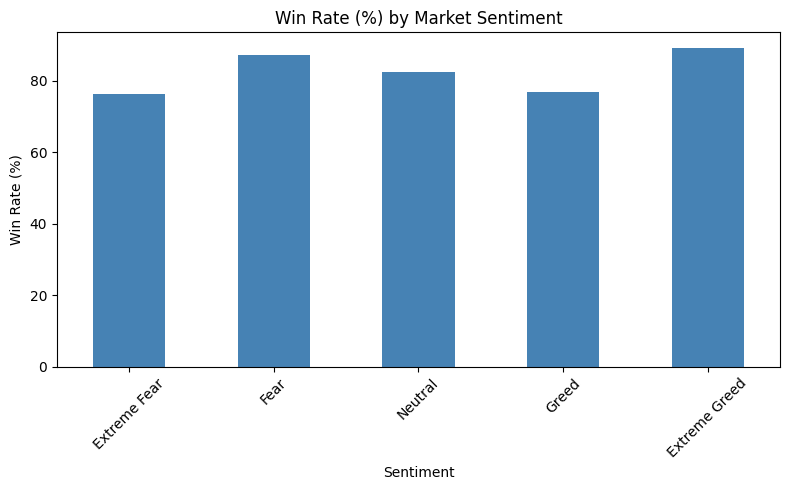

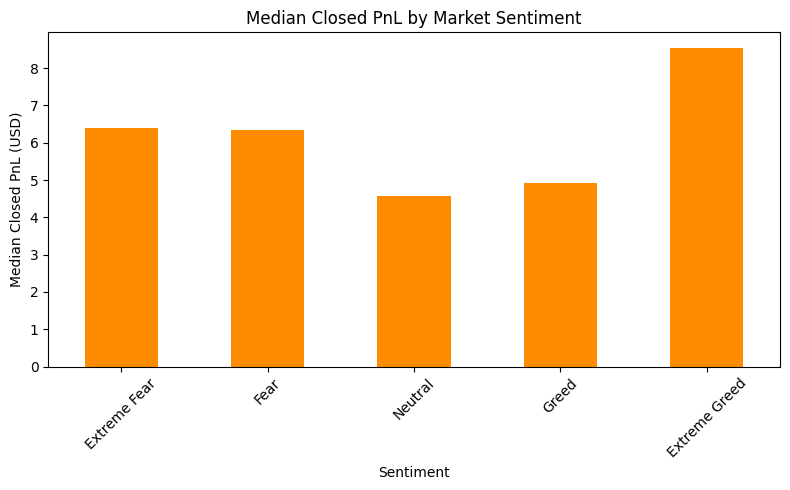

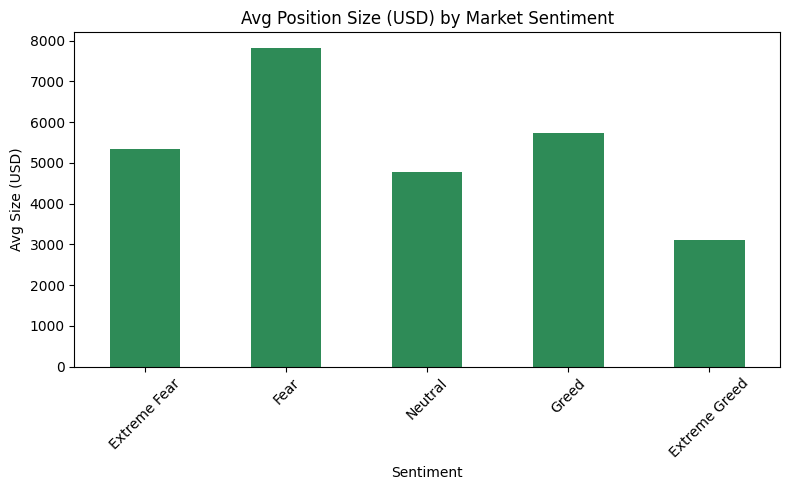

In [12]:
import matplotlib.pyplot as plt

# Define a consistent sentiment order for all charts (worst to best fear/greed spectrum)
# rather than alphabetical or count-based sorting — makes charts easier to read left-to-right.
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# --- Chart 1: Win Rate by Sentiment ---
plt.figure(figsize=(8, 5))
win_rate_by_sentiment.reindex(sentiment_order).plot(kind='bar', color='steelblue')
plt.title('Win Rate (%) by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/win_rate_by_sentiment.png')  # save for README/repo
plt.show()

# --- Chart 2: Median Closed PnL by Sentiment ---
# Using median, not mean, since we established PnL is heavily right-skewed
# and median better represents the "typical" trade outcome.
plt.figure(figsize=(8, 5))
pnl_stats['median'].reindex(sentiment_order).plot(kind='bar', color='darkorange')
plt.title('Median Closed PnL by Market Sentiment')
plt.ylabel('Median Closed PnL (USD)')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/median_pnl_by_sentiment.png')
plt.show()

# --- Chart 3: Avg Position Size by Sentiment ---
plt.figure(figsize=(8, 5))
size_by_sentiment.reindex(sentiment_order).plot(kind='bar', color='seagreen')
plt.title('Avg Position Size (USD) by Market Sentiment')
plt.ylabel('Avg Size (USD)')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/avg_size_by_sentiment.png')
plt.show()

In [13]:
# Check if traders lean more long (BUY) or short (SELL) depending on sentiment.
# normalize='index' converts counts to percentages within each sentiment group,
# so we can compare proportions directly regardless of how many trades happened in each regime.
side_by_sentiment = pd.crosstab(merged_df['classification'], merged_df['Side'], normalize='index') * 100
print("Side (%) by Sentiment:")
print(side_by_sentiment.reindex(sentiment_order))

Side (%) by Sentiment:
Side            BUY  SELL
classification           
Extreme Fear     51    49
Fear             49    51
Neutral          50    50
Greed            49    51
Extreme Greed    45    55


In [14]:
# Question: is the sentiment effect coming from traders CHANGING behavior
# based on sentiment, or just different traders being active in different regimes?

# Step A: compute each account's overall win rate (across all their closed trades)
account_win_rate = closed_trades.groupby('Account')['is_win'].mean() * 100

# Step B: compute each account's win rate broken down BY sentiment
# This shows if the same account performs differently in Fear vs Greed.
account_sentiment_win_rate = closed_trades.groupby(['Account', 'classification'])['is_win'].mean() * 100

# Step C: count how many distinct sentiment regimes each account actually traded in.
# If most accounts only ever traded in 1-2 regimes, the sentiment "effect" we found
# earlier may just reflect different trader populations, not behavior change.
regimes_per_account = closed_trades.groupby('Account')['classification'].nunique()

print("How many sentiment regimes the average account traded across:")
print(regimes_per_account.describe())
print()
print("Number of accounts active in all 5 regimes:", (regimes_per_account == 5).sum())
print("Total unique accounts:", closed_trades['Account'].nunique())

How many sentiment regimes the average account traded across:
count   32
mean     5
std      1
min      3
25%      5
50%      5
75%      5
max      5
Name: classification, dtype: float64

Number of accounts active in all 5 regimes: 24
Total unique accounts: 32


In [16]:
# For each account, get their win rate in EACH sentiment they traded,
# then compute the range (max - min) to show how much individual behavior swings.
account_pivot = closed_trades.groupby(['Account', 'classification'])['is_win'].mean().unstack() * 100
account_spread = (account_pivot.max(axis=1) - account_pivot.min(axis=1))

print("Avg win-rate swing per account across sentiment regimes:", account_spread.mean().round(1), "points")
print("Max swing seen for a single account:", round(account_spread.max(), 1), "points")

Avg win-rate swing per account across sentiment regimes: 42.6 points
Max swing seen for a single account: 100.0 points
